### Importação dos dados



In [33]:
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [10]:
faturamento_loja = loja["Preço"].sum()
print(f"O faturamento da loja 1 foi de R${faturamento_loja:.2f}")
faturamento_loja2 = loja2["Preço"].sum()
print(f"O faturamento da loja 2 foi de R${faturamento_loja2:.2f}")

O faturamento da loja 1 foi de R$1534509.12
O faturamento da loja 2 foi de R$1488459.06


In [14]:
faturamento_loja3 = loja3["Preço"].sum()
print(f"O faturamento da loja 3 foi de R${faturamento_loja3:.2f}")
faturamento_loja4 = loja4["Preço"].sum()
print(f"O faturamento da loja 4 foi de R${faturamento_loja4:.2f}")

O faturamento da loja 3 foi de R$1464025.03
O faturamento da loja 4 foi de R$1384497.58


# 2. Vendas por Categoria

In [17]:
quantidade_categoria = (
    dados
    .groupby(["loja", "Categoria do Produto"])
    .size()
    .reset_index(name="Quantidade Vendida")
)

print(quantidade_categoria)


      loja   Categoria do Produto  Quantidade Vendida
0   loja 1             brinquedos                 324
1   loja 1       eletrodomesticos                 312
2   loja 1            eletronicos                 448
3   loja 1        esporte e lazer                 284
4   loja 1  instrumentos musicais                 182
5   loja 1                 livros                 173
6   loja 1                 moveis                 465
7   loja 1  utilidades domesticas                 171
8   loja 2             brinquedos                 313
9   loja 2       eletrodomesticos                 305
10  loja 2            eletronicos                 422
11  loja 2        esporte e lazer                 275
12  loja 2  instrumentos musicais                 224
13  loja 2                 livros                 197
14  loja 2                 moveis                 442
15  loja 2  utilidades domesticas                 181
16  loja 3             brinquedos                 315
17  loja 3       eletrodomes

In [16]:
loja['loja'] = 'loja 1'
loja2['loja'] = 'loja 2'
loja3['loja'] = 'loja 3'
loja4['loja'] = 'loja 4'

dados = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

In [20]:
mais_vendidas = (
    quantidade_categoria
    .sort_values(["loja", "Quantidade Vendida"], ascending=[True, False])
    .groupby("loja")
    .head(1)
)

print(mais_vendidas)

      loja Categoria do Produto  Quantidade Vendida
6   loja 1               moveis                 465
14  loja 2               moveis                 442
22  loja 3               moveis                 499
30  loja 4               moveis                 480


# 3. Média de Avaliação das Lojas


In [22]:
media_avaliacoes = dados.groupby("loja")["Avaliação da compra"].mean()

print(media_avaliacoes)

loja
loja 1    3.976685
loja 2    4.037304
loja 3    4.048326
loja 4    3.995759
Name: Avaliação da compra, dtype: float64


# 4. Produtos Mais e Menos Vendidos

In [23]:
vendas_produtos = (
    dados
    .groupby(["loja", "Produto"])
    .size()
    .reset_index(name="Quantidade Vendida")
)

print(vendas_produtos.head())

     loja             Produto  Quantidade Vendida
0  loja 1  Assistente virtual                  40
1  loja 1             Bateria                  53
2  loja 1           Bicicleta                  54
3  loja 1    Blocos de montar                  56
4  loja 1    Bola de basquete                  55


In [27]:
mais_vendidos = (
    vendas_produtos
    .sort_values(["loja", "Quantidade Vendida"], ascending=[True, False])
    .groupby("loja")
    .head(1)
)
print(mais_vendidos)

       loja                   Produto  Quantidade Vendida
24   loja 1             Guarda roupas                  60
79   loja 2  Iniciando em programação                  65
134  loja 3             Kit banquetas                  57
161  loja 4                  Cama box                  62


In [28]:
menos_vendidos = (
    vendas_produtos
    .sort_values(["loja", "Quantidade Vendida"], ascending=[True, True])
    .groupby("loja")
    .head(1)
)

print(menos_vendidos)

       loja            Produto  Quantidade Vendida
11   loja 1       Celular ABXY                  33
82   loja 2  Jogo de tabuleiro                  32
105  loja 3   Blocos de montar                  35
178  loja 4           Guitarra                  33


# 5. Frete Médio por Loja

In [29]:
frete_medio = dados.groupby("loja")["Frete"].mean()

print(frete_medio)

loja
loja 1    34.691805
loja 2    33.621941
loja 3    33.074464
loja 4    31.278997
Name: Frete, dtype: float64


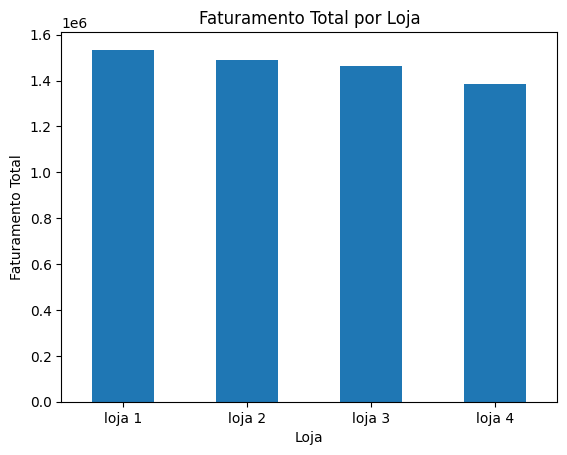

In [34]:
faturamento = dados.groupby("loja")["Preço"].sum()

plt.figure()
faturamento.plot(kind="bar")
plt.title("Faturamento Total por Loja")
plt.xlabel("Loja")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=0)
plt.show()

/tmp/ipython-input-2088682196.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dados["Data da Compra"] = pd.to_datetime(dados["Data da Compra"])


<Figure size 640x480 with 0 Axes>

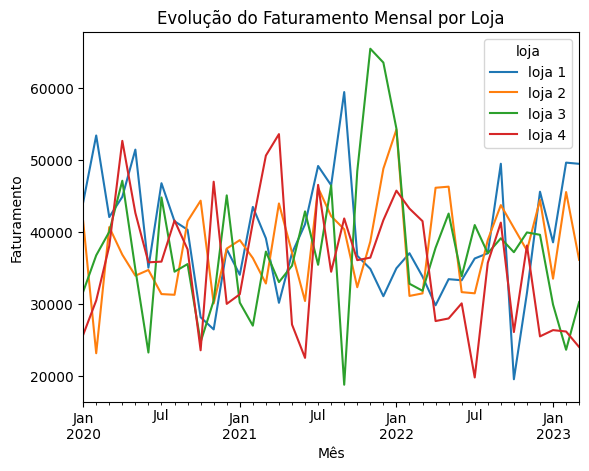

In [36]:
dados["Data da Compra"] = pd.to_datetime(dados["Data da Compra"])
dados["Mes"] = dados["Data da Compra"].dt.to_period("M")

vendas_mensais = dados.groupby(["Mes", "loja"])["Preço"].sum().unstack()

plt.figure()
vendas_mensais.plot()
plt.title("Evolução do Faturamento Mensal por Loja")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.show()

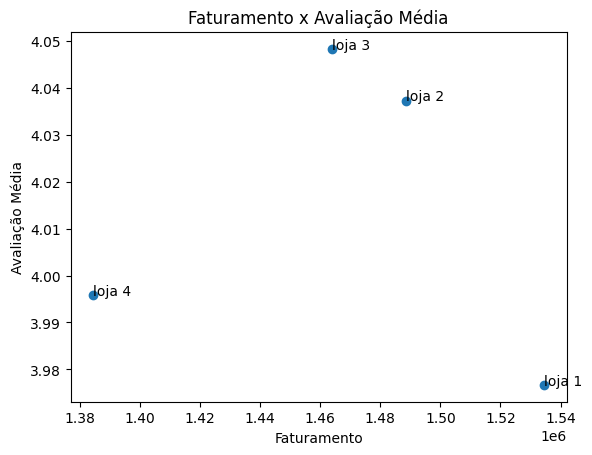

In [38]:
faturamento = dados.groupby("loja")["Preço"].sum()
avaliacao_media = dados.groupby("loja")["Avaliação da compra"].mean()

plt.figure()
plt.scatter(faturamento, avaliacao_media)

for loja in faturamento.index:
    plt.annotate(loja, (faturamento[loja], avaliacao_media[loja]))

plt.title("Faturamento x Avaliação Média")
plt.xlabel("Faturamento")
plt.ylabel("Avaliação Média")
plt.show()

📊 Relatório Final — Análise de Desempenho das Lojas Alura Store

1️⃣ Introdução

O presente relatório tem como objetivo analisar o desempenho das quatro lojas da rede Alura Store, a fim de identificar qual unidade apresenta menor eficiência operacional e deve ser vendida para viabilizar um novo empreendimento do Senhor João.

Foram analisados os seguintes indicadores:

Faturamento total

Categorias mais e menos vendidas

Produtos mais e menos vendidos

Média de avaliações dos clientes

Custo médio de frete

As análises foram apoiadas por visualizações gráficas para facilitar a interpretação dos resultados.

2️⃣ Desenvolvimento da Análise
💰 Faturamento Total

Loja 1: R$ 1.534.509,12

Loja 2: R$ 1.488.459,06

Loja 3: R$ 1.464.025,03

Loja 4: R$ 1.384.497,58

A Loja 1 apresentou o maior faturamento, enquanto a Loja 4 registrou o menor desempenho financeiro.

O gráfico de barras evidencia que a Loja 4 está abaixo das demais, com diferença relevante em relação à líder.

📦 Categorias Mais Vendidas

Em todas as lojas, a categoria móveis foi a mais vendida:

Loja 1: 465 vendas

Loja 2: 442 vendas

Loja 3: 499 vendas

Loja 4: 480 vendas

A Loja 3 lidera em volume dentro dessa categoria.

No geral, as categorias apresentam volumes relativamente equilibrados entre as lojas, o que indica que o problema da Loja 4 não está necessariamente no mix de produtos.

🏆 Produtos Mais Vendidos

Produtos destaque:

Loja 1: Guarda-roupas (60 vendas)

Loja 2: Livro “Iniciando em Programação” (65 vendas)

Loja 3: Kit Banquetas (57 vendas)

Loja 4: Cama Box (62 vendas)

A Loja 4 possui um produto forte (Cama Box), porém isso não foi suficiente para elevar seu faturamento total.

Produtos menos vendidos mostram padrões semelhantes entre lojas, sem discrepâncias críticas.

⭐ Avaliação Média dos Clientes

Loja 1: 3,97

Loja 2: 4,03

Loja 3: 4,05

Loja 4: 3,99

A Loja 3 apresenta a melhor avaliação média.
A Loja 1 tem a menor média.

A Loja 4 não possui a pior avaliação, mas também não se destaca positivamente.

🚚 Frete Médio

Loja 1: R$ 34,69

Loja 2: R$ 33,62

Loja 3: R$ 33,07

Loja 4: R$ 31,27

A Loja 4 possui o menor frete médio, o que é um ponto positivo competitivo.

Por outro lado, mesmo com frete mais barato, a loja apresenta o menor faturamento.

3️⃣ Análise Estratégica Integrada

Ao cruzar os indicadores:

Loja	Faturamento	Avaliação	Frete	Categoria Forte
Loja 1	🥇 Maior	Menor nota	Frete mais alto	Forte
Loja 2	Boa	Boa	Médio	Forte
Loja 3	Boa	🥇 Melhor nota	Médio	🥇 Maior volume
Loja 4	❌ Menor faturamento	Média	🥇 Menor frete	Forte

Observação crítica:

A Loja 4 possui:

O menor faturamento total

Avaliação mediana

Produto destaque, mas sem impacto suficiente

Mesmo com frete mais baixo, não converte em maior receita

Isso sugere menor eficiência comercial ou menor potencial de crescimento comparado às demais.

4️⃣ Conclusão e Recomendação

Com base nas análises realizadas, recomenda-se que o Senhor João considere a venda da Loja 4.

Justificativas principais:

Apresenta o menor faturamento entre as quatro unidades.

Não possui vantagem competitiva clara que compense sua menor geração de receita.

Mesmo com o menor frete médio (ponto positivo), isso não se traduz em melhor desempenho financeiro.

As demais lojas apresentam melhor equilíbrio entre faturamento, avaliação e volume de vendas.

Portanto, do ponto de vista estratégico e financeiro, a Loja 4 demonstra ser a unidade menos eficiente da rede e a mais indicada para venda.